In [2]:
!pip install yfinance scikit-learn

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 1.9 MB/s  0:00:04m0:00:0100:01
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15635 sha256=73fdeae9bbd098f8c334d7c0256070887760dd2e5d7cad6716d7db612fc271e6
  Stored in directory: /home/nyct_cg/.cache/pip/wheels/cc/bd/6f/664d62c99327abeef7d86489e6631cbf45b56fbf7ef1d6ef00
Successfully built multitasking
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [yfinance]5/6 [yfinance]]]


In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [4]:
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400513  72.460776  71.156674  71.409778  135480400
2020-01-03  71.696655  72.455974  71.472477  71.629160  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928070  72.533110  71.708710  72.277594  108872000
2020-01-08  73.085121  73.386438  71.631567  71.631567  132079200


In [5]:
df['Next_Close'] = df['Close'].shift(-1)

# Drop last row (no target)
df = df.dropna()

In [6]:
features = ['Open', 'High', 'Low', 'Volume']
X = df[features]
y = df['Next_Close']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [8]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [9]:
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [10]:
lr_mse = mean_squared_error(y_test, lr_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

print("Linear Regression MSE:", lr_mse)
print("Random Forest MSE:", rf_mse)

Linear Regression MSE: 9.620181742829443
Random Forest MSE: 674.237024542675


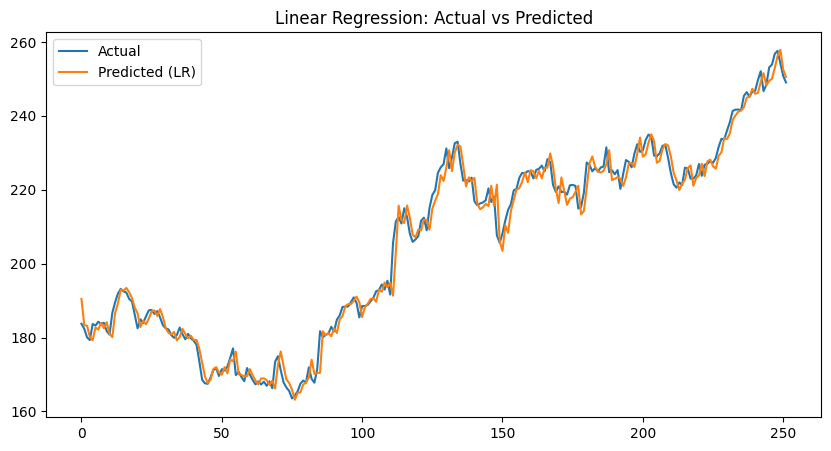

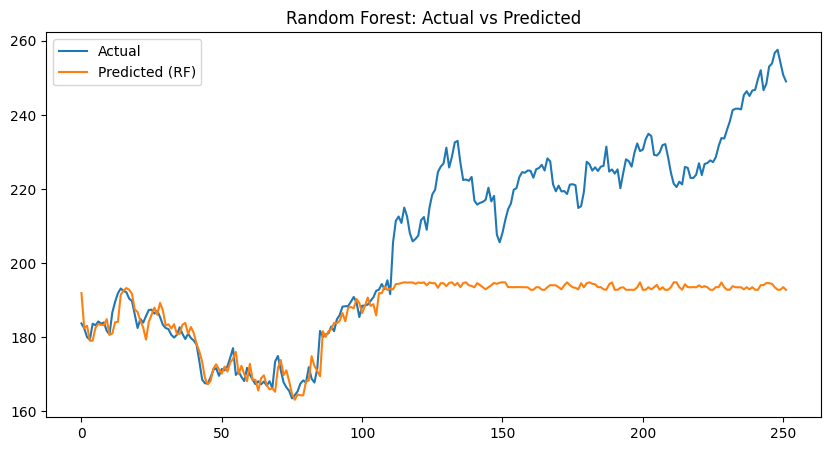

In [11]:
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(lr_pred, label='Predicted (LR)')
plt.legend()
plt.title("Linear Regression: Actual vs Predicted")
plt.show()
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(rf_pred, label='Predicted (RF)')
plt.legend()
plt.title("Random Forest: Actual vs Predicted")
plt.show()